# 07 — Air Quality Classification

**Goal:** Classify daily NO2 levels into air quality categories. Instead of predicting exact values, predict whether tomorrow will be **Good, Moderate or Unhealthy**.

### Why Classification?
- Policy makers don't care if NO2 is 45 or 48. They care: should we issue a health warning?
- Classification turns continuous forecasts into **actionable decisions**
- Combines everything from Notebooks 01-06 as features

### WHO/UK Air Quality Categories for NO2 (daily mean)
| Category | NO2 (µg/m³) | Action |
|----------|-------------|--------|
| **Good** | < 40 | No action needed |
| **Moderate** | 40–60 | Sensitive groups should limit outdoor activity |
| **Unhealthy** | > 60 | Health warning for general population |

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100

print("All imports loaded ✓")

All imports loaded ✓


## 1. Load Data & Create Target Labels

Air Quality Distribution:

  Good      :   669 days (38.2%)
  Moderate  :   690 days (39.4%)
  Unhealthy :   393 days (22.4%)


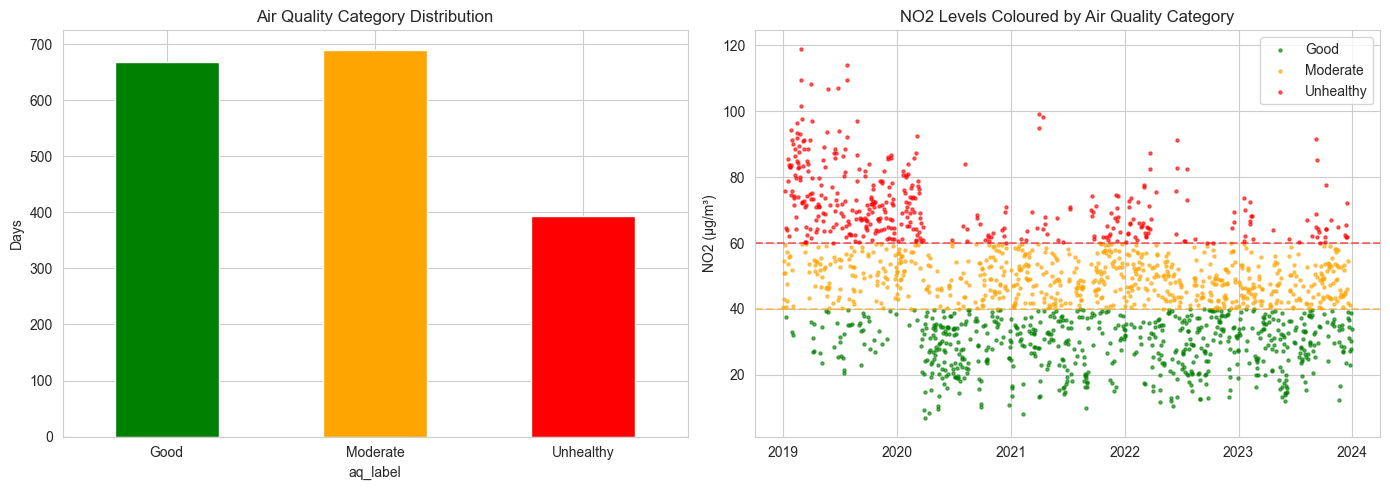

In [2]:
DB_PATH = "../database/air_quality.db"
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql("SELECT * FROM clean_daily_my1", conn, parse_dates=["timestamp"])
df.set_index("timestamp", inplace=True)
conn.close()

# Create air quality labels
def classify_no2(value):
    if value < 40:
        return "Good"
    elif value <= 60:
        return "Moderate"
    else:
        return "Unhealthy"

df["aq_label"] = df["no2"].apply(classify_no2)

# Distribution
label_counts = df["aq_label"].value_counts()
print("Air Quality Distribution:\n")
for label in ["Good", "Moderate", "Unhealthy"]:
    count = label_counts.get(label, 0)
    pct = count / len(df) * 100
    print(f"  {label:10s}: {count:5d} days ({pct:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
label_counts[["Good", "Moderate", "Unhealthy"]].plot(kind="bar", ax=axes[0],
    color=["green", "orange", "red"])
axes[0].set_title("Air Quality Category Distribution")
axes[0].set_ylabel("Days")
plt.sca(axes[0])
plt.xticks(rotation=0)

# Timeline
colors = {"Good": "green", "Moderate": "orange", "Unhealthy": "red"}
for label, color in colors.items():
    mask = df["aq_label"] == label
    axes[1].scatter(df.index[mask], df["no2"][mask], c=color, s=5, label=label, alpha=0.6)
axes[1].set_title("NO2 Levels Coloured by Air Quality Category")
axes[1].set_ylabel("NO2 (µg/m³)")
axes[1].axhline(40, color="orange", linestyle="--", alpha=0.5)
axes[1].axhline(60, color="red", linestyle="--", alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()

## 2. Feature Engineering

Create features that capture time series dynamics — lagged values, rolling statistics, day of week, weather context.

In [3]:
# Feature engineering
feat = df.copy()

# Lag features (yesterday, 2 days ago, 7 days ago)
for lag in [1, 2, 3, 7]:
    feat[f"no2_lag{lag}"] = feat["no2"].shift(lag)
    feat[f"o3_lag{lag}"] = feat["o3"].shift(lag)

# Rolling statistics
for window in [7, 14, 30]:
    feat[f"no2_roll_mean_{window}"] = feat["no2"].shift(1).rolling(window).mean()
    feat[f"no2_roll_std_{window}"] = feat["no2"].shift(1).rolling(window).std()

# Day of week (one-hot)
feat["day_of_week"] = feat.index.dayofweek
feat["is_weekend"] = (feat["day_of_week"] >= 5).astype(int)

# Month
feat["month"] = feat.index.month

# Daily change
feat["no2_change"] = feat["no2"].diff()

# Drop rows with NaN from lagging
feat = feat.dropna()

# Define features and target
feature_cols = [c for c in feat.columns if c not in ["no2", "aq_label"]]
X = feat[feature_cols]
y = feat["aq_label"]

print(f"Features: {len(feature_cols)}")
print(f"Samples: {len(X)}")
print(f"\nFeature list:")
for i, col in enumerate(feature_cols):
    print(f"  {i+1:2d}. {col}")

Features: 25
Samples: 1722

Feature list:
   1. o3
   2. so2
   3. temperature
   4. windspeed
   5. winddirection
   6. precipitation
   7. humidity
   8. no2_lag1
   9. o3_lag1
  10. no2_lag2
  11. o3_lag2
  12. no2_lag3
  13. o3_lag3
  14. no2_lag7
  15. o3_lag7
  16. no2_roll_mean_7
  17. no2_roll_std_7
  18. no2_roll_mean_14
  19. no2_roll_std_14
  20. no2_roll_mean_30
  21. no2_roll_std_30
  22. day_of_week
  23. is_weekend
  24. month
  25. no2_change


## 3. Time-Based Train/Test Split

We use the **same temporal split** as previous notebooks — no random splitting for time series.

In [4]:
TEST_SIZE = 90

X_train, X_test = X[:-TEST_SIZE], X[-TEST_SIZE:]
y_train, y_test = y[:-TEST_SIZE], y[-TEST_SIZE:]

print(f"Train: {len(X_train)} days ({X_train.index.min().date()} → {X_train.index.max().date()})")
print(f"Test:  {len(X_test)} days ({X_test.index.min().date()} → {X_test.index.max().date()})")
print(f"\nTrain class distribution:")
print(y_train.value_counts().to_string())
print(f"\nTest class distribution:")
print(y_test.value_counts().to_string())

Train: 1632 days (2019-01-31 → 2023-10-01)
Test:  90 days (2023-10-02 → 2023-12-30)

Train class distribution:
aq_label
Good         635
Moderate     630
Unhealthy    367

Test class distribution:
aq_label
Moderate     46
Good         32
Unhealthy    12


## 4. Train & Compare Classifiers

In [5]:
# Train 3 classifiers
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {"model": model, "predictions": y_pred, "accuracy": acc}
    print(f"{name:25s} | Accuracy: {acc:.3f} ({acc*100:.1f}%)")

# Find best
best_name = max(results, key=lambda k: results[k]["accuracy"])
print(f"\nBest model: {best_name} ({results[best_name]['accuracy']*100:.1f}%)")

Logistic Regression       | Accuracy: 0.900 (90.0%)
Random Forest             | Accuracy: 0.811 (81.1%)
Gradient Boosting         | Accuracy: 0.922 (92.2%)

Best model: Gradient Boosting (92.2%)


## 5. Best Model — Detailed Evaluation

Classification Report — Gradient Boosting

              precision    recall  f1-score   support

        Good       0.91      1.00      0.96        32
    Moderate       0.93      0.91      0.92        46
   Unhealthy       0.90      0.75      0.82        12

    accuracy                           0.92        90
   macro avg       0.92      0.89      0.90        90
weighted avg       0.92      0.92      0.92        90



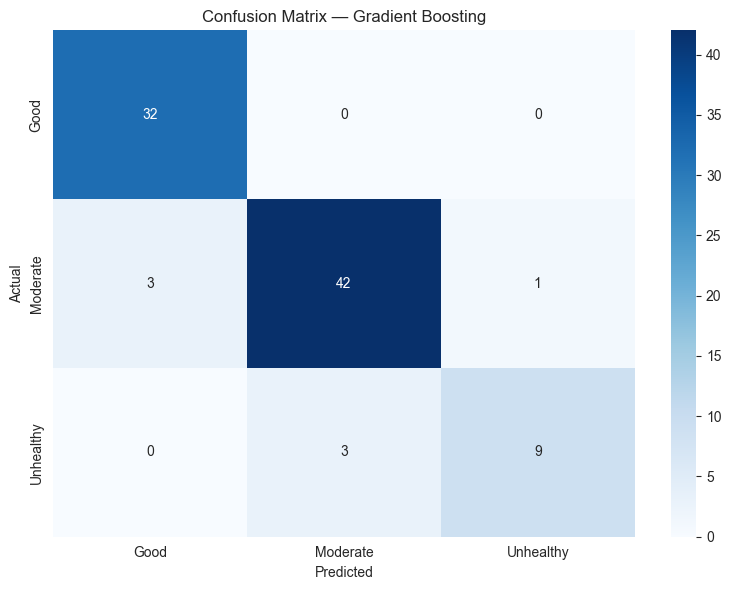


Misclassified days: 7 out of 90 (7.8%)

Misclassified examples:
  2023-10-06 | NO2: 60.2 | Actual: Unhealthy | Predicted: Moderate
  2023-10-23 | NO2: 59.0 | Actual: Moderate | Predicted: Unhealthy
  2023-10-25 | NO2: 43.2 | Actual: Moderate | Predicted: Good
  2023-12-08 | NO2: 62.3 | Actual: Unhealthy | Predicted: Moderate
  2023-12-11 | NO2: 61.9 | Actual: Unhealthy | Predicted: Moderate
  2023-12-16 | NO2: 46.1 | Actual: Moderate | Predicted: Good
  2023-12-18 | NO2: 41.8 | Actual: Moderate | Predicted: Good


In [6]:
# Classification report
best_pred = results[best_name]["predictions"]
print(f"Classification Report — {best_name}\n")
print(classification_report(y_test, best_pred))

# Confusion matrix
cm = confusion_matrix(y_test, best_pred, labels=["Good", "Moderate", "Unhealthy"])
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Good", "Moderate", "Unhealthy"],
            yticklabels=["Good", "Moderate", "Unhealthy"], ax=ax)
ax.set_title(f"Confusion Matrix — {best_name}")
ax.set_ylabel("Actual")
ax.set_xlabel("Predicted")
plt.tight_layout()
plt.show()

# Misclassification analysis
misclassified = X_test.index[best_pred != y_test]
print(f"\nMisclassified days: {len(misclassified)} out of {len(y_test)} ({len(misclassified)/len(y_test)*100:.1f}%)")
if len(misclassified) > 0:
    print("\nMisclassified examples:")
    for idx in misclassified[:10]:
        actual = y_test.loc[idx]
        predicted = best_pred[y_test.index.get_loc(idx)]
        no2_val = df.loc[idx, "no2"]
        print(f"  {idx.date()} | NO2: {no2_val:.1f} | Actual: {actual} | Predicted: {predicted}")

## 6. Feature Importance — What Drives the Classification?

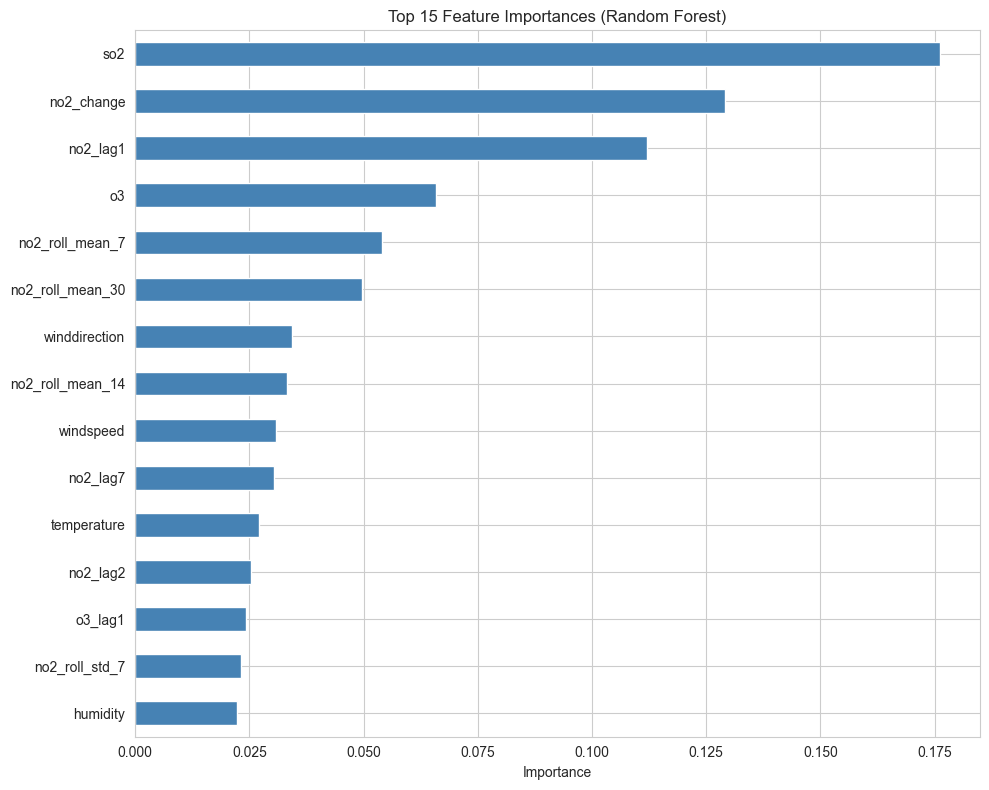

Top 5 most important features:
  1. so2: 0.1761 (17.6%)
  2. no2_change: 0.1291 (12.9%)
  3. no2_lag1: 0.1121 (11.2%)
  4. o3: 0.0660 (6.6%)
  5. no2_roll_mean_7: 0.0541 (5.4%)


In [7]:
# Feature importance from Random Forest (even if not best, it gives importance)
rf = results["Random Forest"]["model"]
importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
importance.tail(15).plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 Feature Importances (Random Forest)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
for i, (feat_name, imp) in enumerate(importance.tail(5).iloc[::-1].items(), 1):
    print(f"  {i}. {feat_name}: {imp:.4f} ({imp*100:.1f}%)")

## 7. Timeline — Predicted vs Actual Air Quality

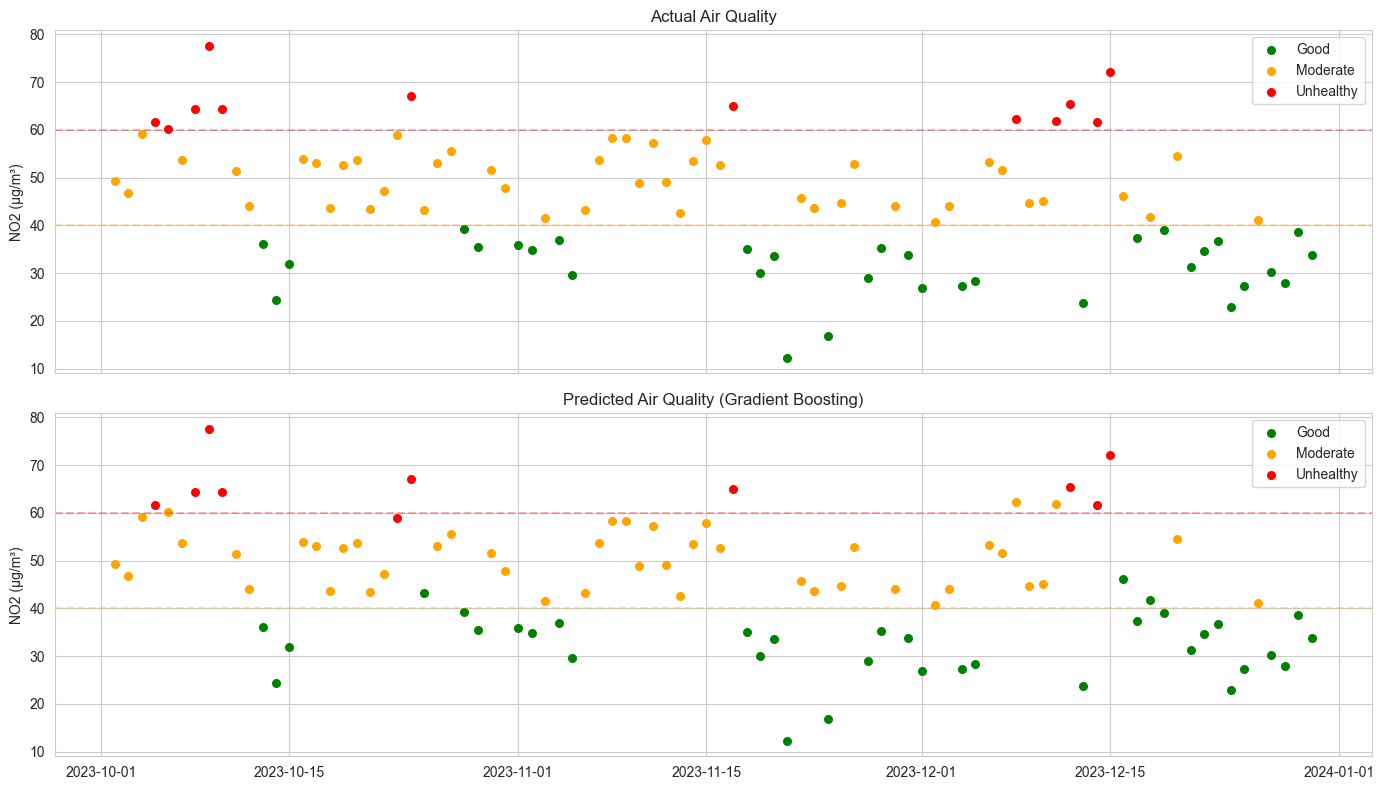

In [8]:
# Timeline comparison
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

color_map = {"Good": "green", "Moderate": "orange", "Unhealthy": "red"}

# Actual
for label, color in color_map.items():
    mask = y_test == label
    axes[0].scatter(X_test.index[mask], df.loc[X_test.index[mask], "no2"],
                    c=color, s=30, label=label)
axes[0].axhline(40, color="orange", linestyle="--", alpha=0.3)
axes[0].axhline(60, color="red", linestyle="--", alpha=0.3)
axes[0].set_title("Actual Air Quality")
axes[0].set_ylabel("NO2 (µg/m³)")
axes[0].legend()

# Predicted
for label, color in color_map.items():
    mask = best_pred == label
    axes[1].scatter(X_test.index[mask], df.loc[X_test.index[mask], "no2"],
                    c=color, s=30, label=label)
axes[1].axhline(40, color="orange", linestyle="--", alpha=0.3)
axes[1].axhline(60, color="red", linestyle="--", alpha=0.3)
axes[1].set_title(f"Predicted Air Quality ({best_name})")
axes[1].set_ylabel("NO2 (µg/m³)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Final Project Summary — All Notebooks

In [11]:
best_acc = results[best_name]["accuracy"]


print(f"\n--- Classification Results ---")
print(f"• Best classifier: {best_name} ({best_acc*100:.1f}% accuracy)")
print(f"• 3 models compared: Logistic Regression, Random Forest, Gradient Boosting")
print(f"• Misclassified: {len(misclassified)} out of {len(y_test)} test days")

print(f"\n--- All Models Across Project ---")
print(f"{'Notebook':<25} {'Model':<35} {'Key Metric'}")
print("-" * 85)
print(f"{'02 ARIMA':<25} {'ARIMA(1,1,2)':<35} {'RMSE 11.61 (walk-forward)'}")
print(f"{'03 SARIMA':<25} {'SARIMA(1,1,2)(1,1,2,7)':<35} {'RMSE 11.97 (walk-forward)'}")
print(f"{'04 VAR':<25} {'VAR(12)':<35} {'RMSE 31.14 (walk-forward)'}")
print(f"{'05 GARCH':<25} {'ARIMA-GARCH(1,1)':<35} {'95.6% CI coverage'}")
print(f"{'06 Anomaly':<25} {'Consensus (3 methods)':<35} {'66 anomaly days detected'}")
print(f"{'07 Classification':<25} {best_name:<35} {f'{best_acc*100:.1f}% accuracy'}")

print(f"\n--- Key Insights ---")
print(f"• NO2 is 93% self-driven (FEVD)")
print(f"• Simple models beat complex ones for point forecasting")
print(f"• GARCH adds value through dynamic uncertainty, not better predictions")
print(f"• Anomalies declining: 28 (2019) → 5 (2023)")
print(f"• Classification enables actionable air quality alerts")



--- Classification Results ---
• Best classifier: Gradient Boosting (92.2% accuracy)
• 3 models compared: Logistic Regression, Random Forest, Gradient Boosting
• Misclassified: 7 out of 90 test days

--- All Models Across Project ---
Notebook                  Model                               Key Metric
-------------------------------------------------------------------------------------
02 ARIMA                  ARIMA(1,1,2)                        RMSE 11.61 (walk-forward)
03 SARIMA                 SARIMA(1,1,2)(1,1,2,7)              RMSE 11.97 (walk-forward)
04 VAR                    VAR(12)                             RMSE 31.14 (walk-forward)
05 GARCH                  ARIMA-GARCH(1,1)                    95.6% CI coverage
06 Anomaly                Consensus (3 methods)               66 anomaly days detected
07 Classification         Gradient Boosting                   92.2% accuracy

--- Key Insights ---
• NO2 is 93% self-driven (FEVD)
• Simple models beat complex ones for point 